# 개별 탐색 노트북 — 대체 전처리 기준

원본 통합노트북 셀 64~123. 최종 발표자료에는 반영되지 않은 개별 실험 버전입니다. 다른 전처리 기준(eyesight ≤ 2.0, BMI 6구간 라벨, 연령 4구간)을 사용해 team_final과 결과가 다를 수 있습니다. 자세한 차이는 `docs/03_issues_and_troubleshooting.md` 참고.

## 기본 전처리

In [ ]:
!sudo apt-get install -y fonts-nanum                  # 나눔 폰트 설치
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontcon

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as ma

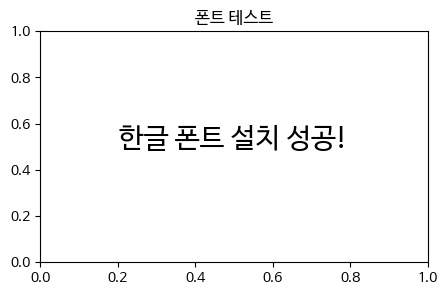

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')           # 한글 폰트 설정 테스트
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5, 3))                          # 설치 확인
plt.text(0.5, 0.5, '한글 폰트 설치 성공!', size=20, ha='center')
plt.title('폰트 테스트')
plt.show()

In [ ]:
# 1) CSV 파일을 읽어 DataFrame 생성
manu_path = '/content/train_dataset.csv'        # train_dataset.csv 파일 경로 입력

df = pd.read_csv(manu_path)


df.head(5)                                      # df의x 상위 5개 행을 확인하고 출력

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [ ]:
df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)        # BMI 추가
df['WHtR'] = df['waist(cm)'] / df['height(cm)']                       # WHtR 추가

display(df[['height(cm)', 'weight(kg)', 'waist(cm)', 'BMI', 'WHtR']].head())

,height(cm),weight(kg),waist(cm),BMI,WHtR
0,170,85,97.0,29.411765,0.570588
1,175,110,110.0,35.918367,0.628571
2,155,65,86.0,27.055151,0.554839
3,165,80,94.0,29.384757,0.569697
4,165,60,81.0,22.038567,0.490909


In [ ]:
# 필터적용
train_clean = df[
    (df['Gtp'] < 500) &
    (df['ALT'] < 500) &
    (df['AST'] < 500) &
    (df['LDL'] < 400) &
    (df['serum creatinine'] < 3.0) &
    (df['eyesight(left)'] <= 2.0) &
    (df['eyesight(right)'] <= 2.0)
].copy()
train_clean.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,WHtR
count,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,...,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000
mean,44.077568,164.695534,65.941533,82.047630,0.999411,0.993645,1.025013,1.025761,121.442204,75.980305,...,14.623696,1.085003,0.884228,25.877956,26.692669,38.710712,0.214584,0.366882,24.179562,0.498551
std,12.041763,9.191880,12.895172,9.325185,0.326393,0.325241,0.156166,0.158425,13.632417,9.658122,...,1.566662,0.396592,0.191950,13.597727,20.422636,41.335390,0.410539,0.481960,3.502443,0.053220
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.900000,1.000000,0.100000,6.000000,1.000000,3.000000,0.000000,0.000000,14.268728,0.318750
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000,21.604938,0.462353
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000,23.875115,0.495381
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000,26.122449,0.531429
max,85.000000,190.000000,135.000000,129.000000,2.000000,2.000000,2.000000,2.000000,233.000000,146.000000,...,21.100000,6.000000,2.600000,387.000000,471.000000,497.000000,1.000000,1.000000,42.448980,0.798125


In [ ]:
# 나이를 20-35를 '청년', 36-50을 '중년', 51-64 를 '장년', 65 이상 '노년'으로 해서 나이를 4 그룹으로 분류한 값 추가
bins = [0, 35, 50, 64, 150]
labels = ['청년', '중년', '장년', '노년']

train_clean['age_group'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=True)

display(train_clean[['age', 'age_group']].head())

,age,age_group
0,35,청년
1,20,청년
3,45,중년
4,20,청년
5,60,장년


In [ ]:
# BMI 분류 및 항목 추가
bmi_bins = [0, 18.5, 23, 25, 30, 35, 100]
bmi_labels = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

train_clean['bmi_group'] = pd.cut(train_clean['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

display(train_clean[['BMI', 'bmi_group']].head())

,BMI,bmi_group
0,29.411765,1단계 비만
1,35.918367,3단계 비만
3,29.384757,1단계 비만
4,22.038567,정상
5,19.531250,정상


In [ ]:
# 흡연 여부와 다른 항목들 간의 상관 계수 구하기
# 수치형 데이터만 선택하여 상관계수 산출
correlations = train_clean.select_dtypes(include=[np.number]).corr()['smoking'].sort_values(ascending=False)

print("--- 'smoking' 항목과의 상관 계수 ---")
display(correlations)

--- 'smoking' 항목과의 상관 계수 ---


,smoking
smoking,1.000000
hemoglobin,0.402488
height(cm),0.395455
weight(kg),0.301805
Gtp,0.268044
triglyceride,0.251041
serum creatinine,0.247212
waist(cm),0.224976
ALT,0.149201
BMI,0.107735


# 시각화

## 수정 가설 1.흡연은 혈관 관련 건강지표를 악화시킬 것이다.

### 세부가설 1-1: 흡연은 BMI와 무관하게 헤모글로빈 수치를 증가시킬 것이다

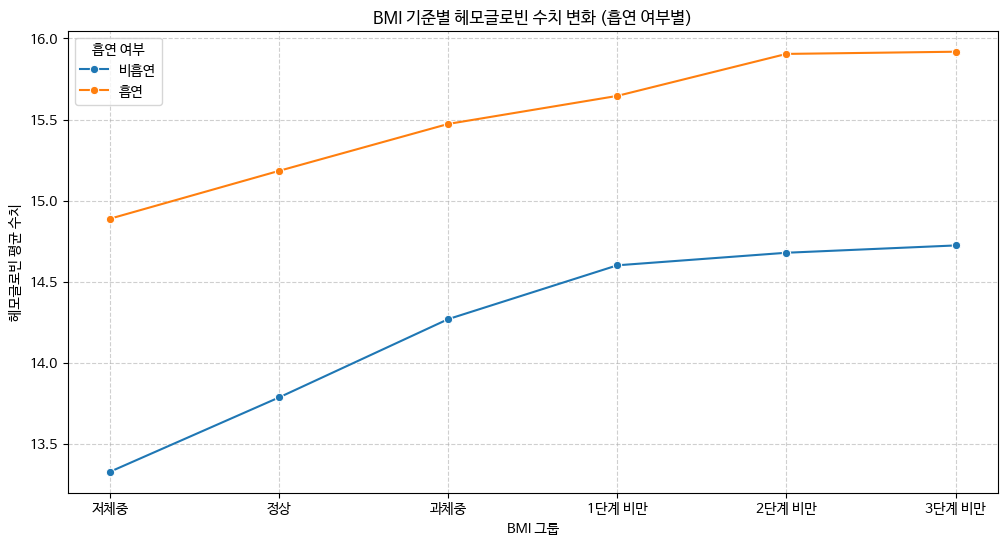

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 그룹 순서 정의
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

# 그래프 스타일 설정
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_clean, x='bmi_group', y='hemoglobin', hue='smoking', marker='o', errorbar=None)

# 범례 및 라벨 설정
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.title('BMI 기준별 헤모글로빈 수치 변화 (흡연 여부별)')
plt.xlabel('BMI 그룹')
plt.ylabel('헤모글로빈 평균 수치')
plt.xticks(ticks=range(len(bmi_order)), labels=bmi_order)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
# BMI 그룹 및 흡연 여부별 헤모글로빈 평균 수치 표 생성
hemo_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['hemoglobin'].mean().unstack()

# 컬럼명 변경 (0: 비흡연, 1: 흡연)
hemo_table.columns = ['비흡연', '흡연']

print("--- BMI 그룹별 헤모글로빈 평균 수치 (흡연 여부별) ---")
display(hemo_table.round(2))

--- BMI 그룹별 헤모글로빈 평균 수치 (흡연 여부별) ---


,비흡연,흡연
bmi_group,,
저체중,13.33,14.89
정상,13.79,15.18
과체중,14.27,15.47
1단계 비만,14.60,15.65
2단계 비만,14.68,15.90
3단계 비만,14.72,15.92


#### 추가 증빙: BMI/헤모글로빈간의 상관계수

In [ ]:
correlation_bmi_hemo = train_clean[['BMI', 'hemoglobin']].corr().iloc[0, 1]
print(f'BMI와 헤모글로빈 간의 상관계수: {correlation_bmi_hemo:.4f}')

BMI와 헤모글로빈 간의 상관계수: 0.2565


### 세부가설 1-2. 흡연자는 비흡연자보다 혈압이 더 높게 나타날 것이다.

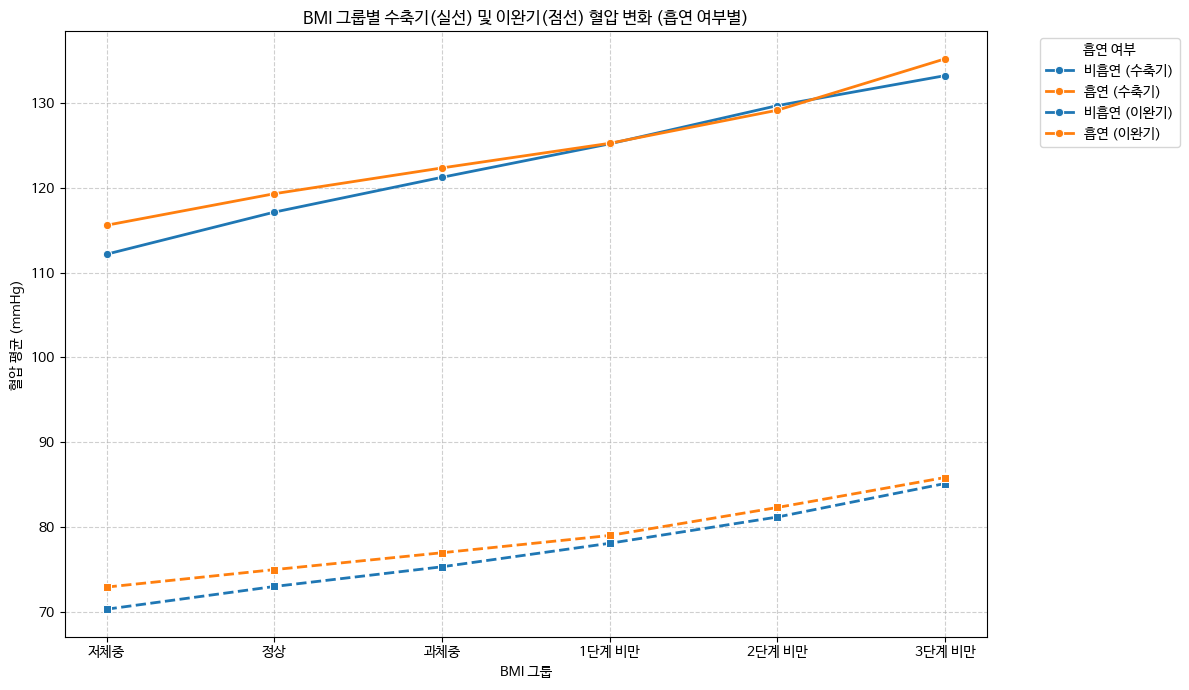

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 그룹 순서 정의
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

# 시각화 설정
plt.figure(figsize=(12, 7))

# 수축기 혈압 (Systolic) - 실선
sns.lineplot(data=train_clean, x='bmi_group', y='systolic', hue='smoking', marker='o', errorbar=None, linewidth=2)

# 이완기 혈압 (Relaxation) - 점선
sns.lineplot(data=train_clean, x='bmi_group', y='relaxation', hue='smoking', marker='s', errorbar=None, linestyle='--', linewidth=2)

# 제목 및 라벨 설정
plt.title('BMI 그룹별 수축기(실선) 및 이완기(점선) 혈압 변화 (흡연 여부별)')
plt.xlabel('BMI 그룹')
plt.ylabel('혈압 평균 (mmHg)')

# 범례 설정 (커스텀)
plt.legend(title='흡연 여부', labels=['비흡연 (수축기)', '흡연 (수축기)', '비흡연 (이완기)', '흡연 (이완기)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
bp_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)[['systolic', 'relaxation']].mean().unstack()
bp_table.columns = ['비흡연_수축기', '흡연_수축기', '비흡연_이완기', '흡연_이완기']
print("--- BMI 그룹별 수축기/이완기 혈압 평균 ---")
display(bp_table.round(1))

--- BMI 그룹별 수축기/이완기 혈압 평균 ---


,비흡연_수축기,흡연_수축기,비흡연_이완기,흡연_이완기
bmi_group,,,,
저체중,112.2,115.6,70.3,72.9
정상,117.1,119.3,73.0,75.0
과체중,121.3,122.4,75.3,77.0
1단계 비만,125.2,125.3,78.1,79.0
2단계 비만,129.7,129.2,81.2,82.3
3단계 비만,133.2,135.2,85.1,85.8


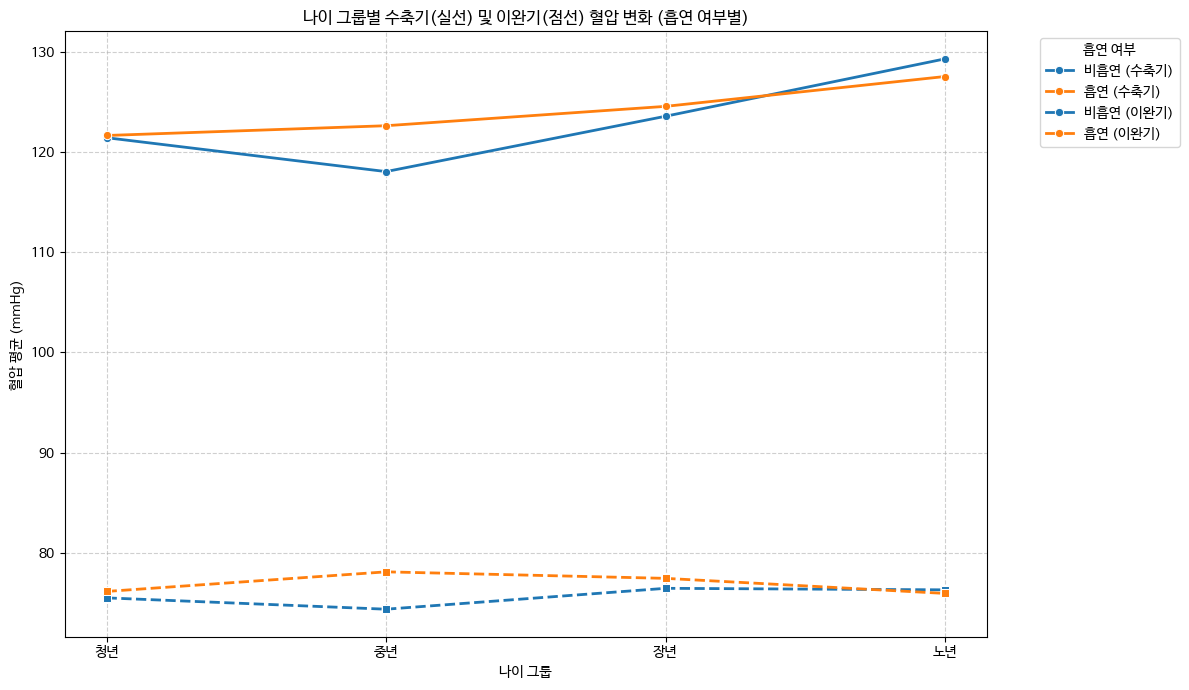

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 나이 그룹 순서 정의
age_order = ['청년', '중년', '장년', '노년']

# 시각화 설정
plt.figure(figsize=(12, 7))

# 수축기 혈압 (Systolic) - 실선
sns.lineplot(data=train_clean, x='age_group', y='systolic', hue='smoking', marker='o', errorbar=None, linewidth=2)

# 이완기 혈압 (Relaxation) - 점선
sns.lineplot(data=train_clean, x='age_group', y='relaxation', hue='smoking', marker='s', errorbar=None, linestyle='--', linewidth=2)

# 제목 및 라벨 설정
plt.title('나이 그룹별 수축기(실선) 및 이완기(점선) 혈압 변화 (흡연 여부별)')
plt.xlabel('나이 그룹')
plt.ylabel('혈압 평균 (mmHg)')

# 범례 설정
plt.legend(title='흡연 여부', labels=['비흡연 (수축기)', '흡연 (수축기)', '비흡연 (이완기)', '흡연 (이완기)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
age_bp_table = train_clean.groupby(['age_group', 'smoking'], observed=False)[['systolic', 'relaxation']].mean().unstack()
age_bp_table.columns = ['비흡연_수축기', '흡연_수축기', '비흡연_이완기', '흡연_이완기']
print("--- 나이 그룹별 수축기/이완기 혈압 평균 ---")
display(age_bp_table.round(1))

--- 나이 그룹별 수축기/이완기 혈압 평균 ---


,비흡연_수축기,흡연_수축기,비흡연_이완기,흡연_이완기
age_group,,,,
청년,121.4,121.6,75.5,76.2
중년,118.0,122.6,74.4,78.1
장년,123.5,124.5,76.5,77.5
노년,129.3,127.5,76.3,76.0


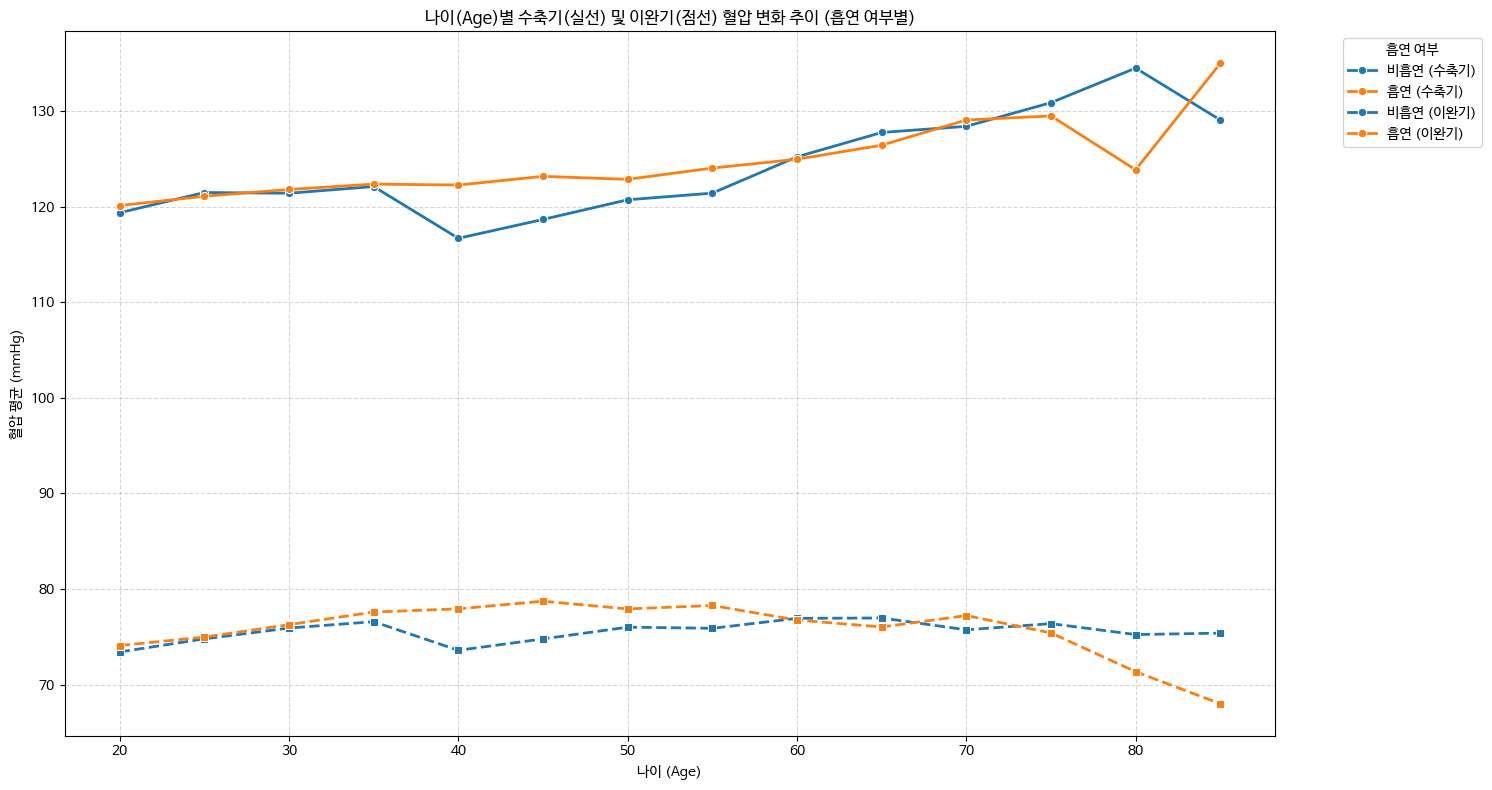

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
plt.figure(figsize=(15, 8))

# 전체 age별 수축기 혈압 (Systolic) - 실선
sns.lineplot(data=train_clean, x='age', y='systolic', hue='smoking', marker='o', errorbar=None, linewidth=2)

# 전체 age별 이완기 혈압 (Relaxation) - 점선
sns.lineplot(data=train_clean, x='age', y='relaxation', hue='smoking', marker='s', errorbar=None, linestyle='--', linewidth=2)

# 제목 및 라벨 설정
plt.title('나이(Age)별 수축기(실선) 및 이완기(점선) 혈압 변화 추이 (흡연 여부별)')
plt.xlabel('나이 (Age)')
plt.ylabel('혈압 평균 (mmHg)')

# 범례 설정
plt.legend(title='흡연 여부', labels=['비흡연 (수축기)', '흡연 (수축기)', '비흡연 (이완기)', '흡연 (이완기)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
raw_age_bp_table = train_clean.groupby(['age', 'smoking'])[['systolic', 'relaxation']].mean().unstack().tail(10)
print("--- 나이(Age)별 혈압 평균 (최근 10개 나이대) ---")
display(raw_age_bp_table.round(1))

--- 나이(Age)별 혈압 평균 (최근 10개 나이대) ---


systolic        relaxation      
smoking        0      1          0     1
age                                     
40         116.7  122.3       73.6  77.9
45         118.7  123.2       74.8  78.7
50         120.7  122.9       76.0  77.9
55         121.4  124.0       75.9  78.3
60         125.2  125.0       76.9  76.8
65         127.8  126.4       77.0  76.0
70         128.4  129.1       75.7  77.2
75         130.9  129.5       76.4  75.4
80         134.5  123.9       75.2  71.3
85         129.1  135.0       75.4  68.0

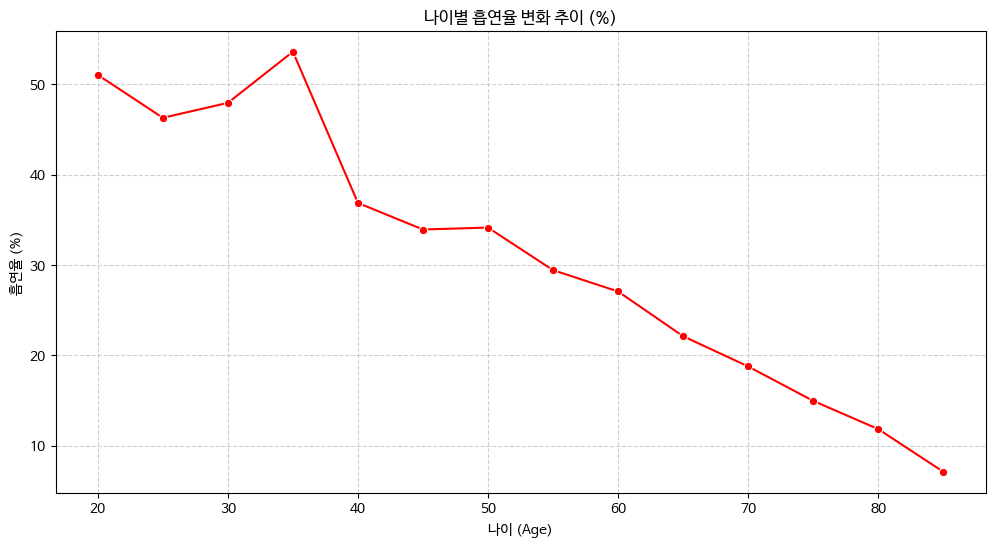

,age,smoking_percent
0,20,51.0
1,25,46.3
2,30,47.9
3,35,53.6
4,40,36.9
5,45,33.9
6,50,34.1
7,55,29.4
8,60,27.1
9,65,22.1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 나이별 흡연율 계산 (백분율로 변환)
smoking_rate_by_age = train_clean.groupby('age')['smoking'].mean().reset_index()
smoking_rate_by_age['smoking_percent'] = smoking_rate_by_age['smoking'] * 100

# 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=smoking_rate_by_age, x='age', y='smoking_percent', marker='o', color='red')

plt.title('나이별 흡연율 변화 추이 (%)')
plt.xlabel('나이 (Age)')
plt.ylabel('흡연율 (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# 상위 10개 행 출력 (소수점 첫째자리까지 반올림)
display(smoking_rate_by_age[['age', 'smoking_percent']].head(10).round(1))

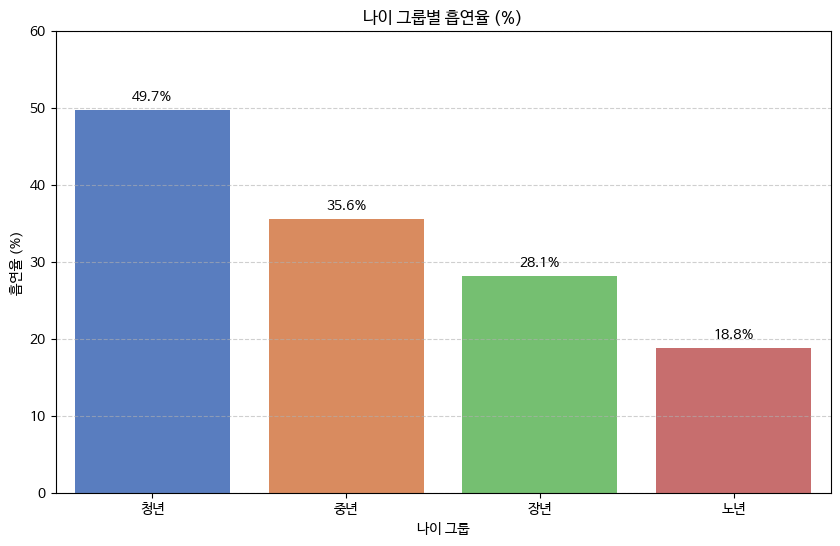

,age_group,smoking_percent
0,청년,49.7
1,중년,35.6
2,장년,28.1
3,노년,18.8


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 나이 그룹별 흡연율 계산 (FutureWarning 방지를 위해 observed=False 추가)
age_group_smoking = train_clean.groupby('age_group', observed=False)['smoking'].mean().reset_index()
age_group_smoking['smoking_percent'] = age_group_smoking['smoking'] * 100

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=age_group_smoking, x='age_group', y='smoking_percent', palette='muted', hue='age_group', legend=False)

# 그래프 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('나이 그룹별 흡연율 (%)')
plt.xlabel('나이 그룹')
plt.ylabel('흡연율 (%)')
plt.ylim(0, 60) # Y축 범위 설정
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# 데이터프레임 출력
display(age_group_smoking[['age_group', 'smoking_percent']].round(1))

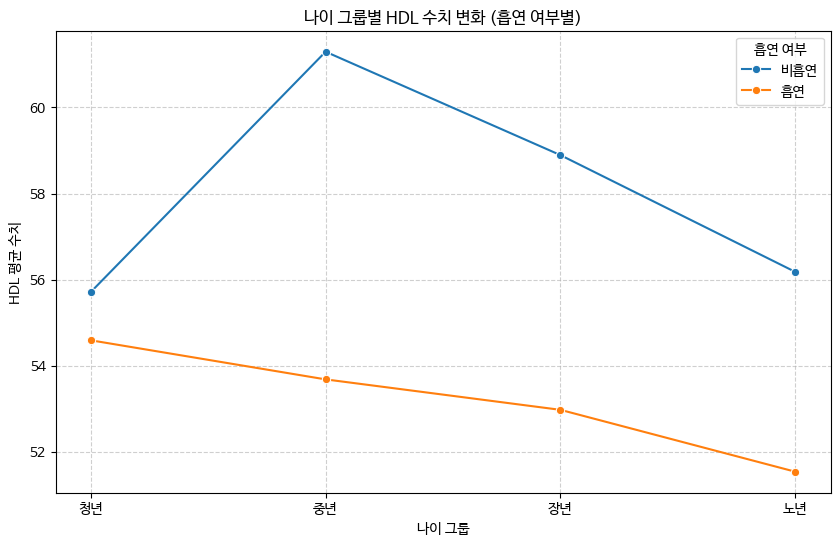

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 나이 그룹별 HDL 수치 시각화
age_order = ['청년', '중년', '장년', '노년']

plt.figure(figsize=(10, 6))
sns.lineplot(data=train_clean, x='age_group', y='HDL', hue='smoking', marker='o', errorbar=None)

plt.title('나이 그룹별 HDL 수치 변화 (흡연 여부별)')
plt.xlabel('나이 그룹')
plt.ylabel('HDL 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
hdl_age_table = train_clean.groupby(['age_group', 'smoking'], observed=False)['HDL'].mean().unstack()
hdl_age_table.columns = ['비흡연', '흡연']
print("--- 나이 그룹별 HDL 평균 수치 ---")
display(hdl_age_table.round(2))

--- 나이 그룹별 HDL 평균 수치 ---


,비흡연,흡연
age_group,,
청년,55.71,54.59
중년,61.30,53.68
장년,58.89,52.97
노년,56.18,51.54


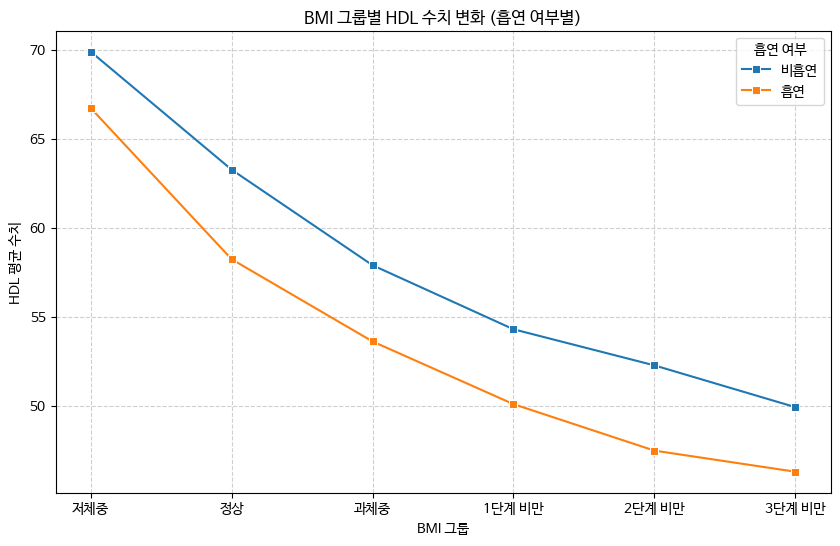

In [ ]:
# 2. BMI 그룹별 HDL 수치 시각화
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

plt.figure(figsize=(10, 6))
sns.lineplot(data=train_clean, x='bmi_group', y='HDL', hue='smoking', marker='s', errorbar=None)

plt.title('BMI 그룹별 HDL 수치 변화 (흡연 여부별)')
plt.xlabel('BMI 그룹')
plt.ylabel('HDL 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
hdl_bmi_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['HDL'].mean().unstack()
hdl_bmi_table.columns = ['비흡연', '흡연']
print("--- BMI 그룹별 HDL 평균 수치 ---")
display(hdl_bmi_table.round(2))

--- BMI 그룹별 HDL 평균 수치 ---


,비흡연,흡연
bmi_group,,
저체중,69.89,66.73
정상,63.26,58.23
과체중,57.89,53.61
1단계 비만,54.30,50.09
2단계 비만,52.27,47.48
3단계 비만,49.92,46.29


#### 추가 증빙: BMI/나이/수축기/이완기/HDL의 상관계수

In [ ]:
cols = ['BMI', 'age', 'systolic', 'relaxation', 'BMI', 'smoking']
correlation_matrix = train_clean[cols].corr()

print("--- BMI, 나이, 혈압 간의 상관계수 ---")
display(correlation_matrix)

--- BMI, 나이, 혈압 간의 상관계수 ---


,BMI,age,systolic,relaxation,BMI,smoking
BMI,1.000000,-0.064601,0.304579,0.284785,1.000000,0.107735
age,-0.064601,1.000000,0.131465,0.048629,-0.064601,-0.167949
systolic,0.304579,0.131465,1.000000,0.759383,0.304579,0.070547
relaxation,0.284785,0.048629,0.759383,1.000000,0.284785,0.104368
BMI,1.000000,-0.064601,0.304579,0.284785,1.000000,0.107735
smoking,0.107735,-0.167949,0.070547,0.104368,0.107735,1.000000


## 수정 가설 2: 흡연은 간 기능 저하를 유발할 것이다

### 세부가설 2-1: 흡연자는 비흡연자보다 간 효소 GTP가 더 높게 나타날 것이다

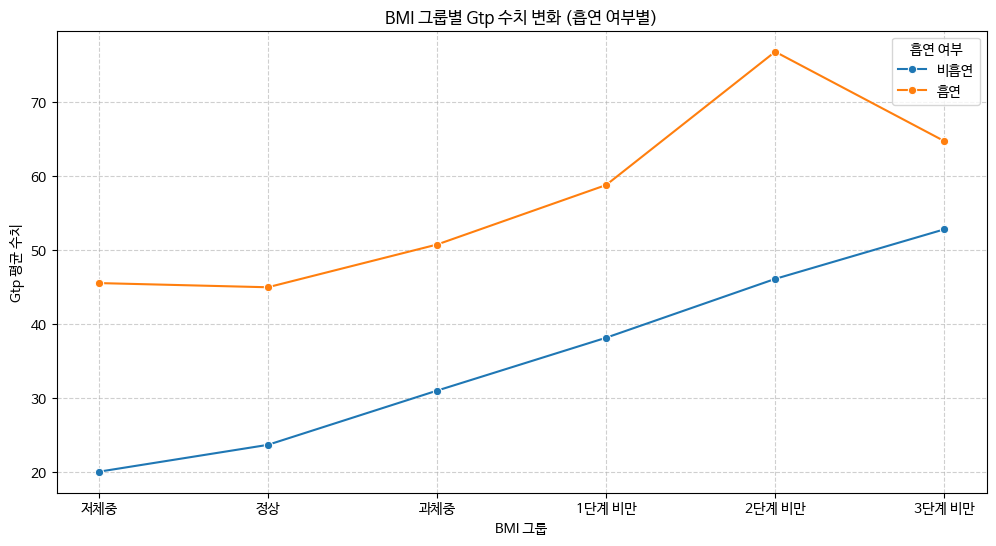

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. BMI 그룹별 Gtp 수치 변화 (흡연 여부별)
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

plt.figure(figsize=(12, 6))
sns.lineplot(data=train_clean, x='bmi_group', y='Gtp', hue='smoking', marker='o', errorbar=None)

plt.title('BMI 그룹별 Gtp 수치 변화 (흡연 여부별)')
plt.xlabel('BMI 그룹')
plt.ylabel('Gtp 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
gtp_bmi_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['Gtp'].mean().unstack()
gtp_bmi_table.columns = ['비흡연', '흡연']
print("--- BMI 그룹별 Gtp 평균 수치 ---")
display(gtp_bmi_table.round(2))

--- BMI 그룹별 Gtp 평균 수치 ---


,비흡연,흡연
bmi_group,,
저체중,20.07,45.58
정상,23.71,45.01
과체중,31.04,50.79
1단계 비만,38.19,58.84
2단계 비만,46.15,76.86
3단계 비만,52.85,64.78


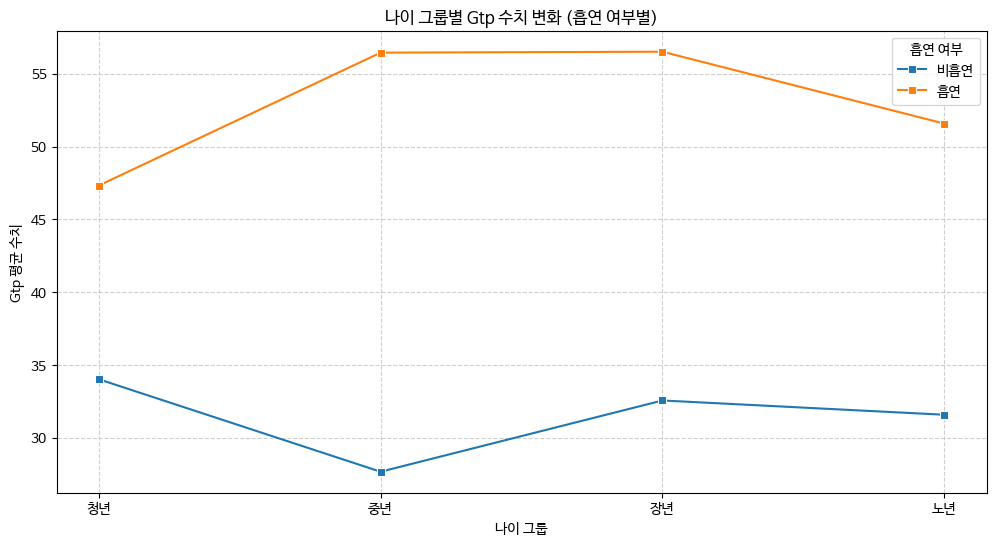

In [ ]:
# 2. 나이 그룹별 Gtp 수치 변화 (흡연 여부별)
age_order = ['청년', '중년', '장년', '노년']

plt.figure(figsize=(12, 6))
sns.lineplot(data=train_clean, x='age_group', y='Gtp', hue='smoking', marker='s', errorbar=None)

plt.title('나이 그룹별 Gtp 수치 변화 (흡연 여부별)')
plt.xlabel('나이 그룹')
plt.ylabel('Gtp 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
gtp_age_table = train_clean.groupby(['age_group', 'smoking'], observed=False)['Gtp'].mean().unstack()
gtp_age_table.columns = ['비흡연', '흡연']
print("--- 나이 그룹별 Gtp 평균 수치 ---")
display(gtp_age_table.round(2))

--- 나이 그룹별 Gtp 평균 수치 ---


,비흡연,흡연
age_group,,
청년,34.01,47.32
중년,27.66,56.45
장년,32.56,56.51
노년,31.58,51.57


### 세부가설 2-2: 흡연자는 ALT 에 악영향

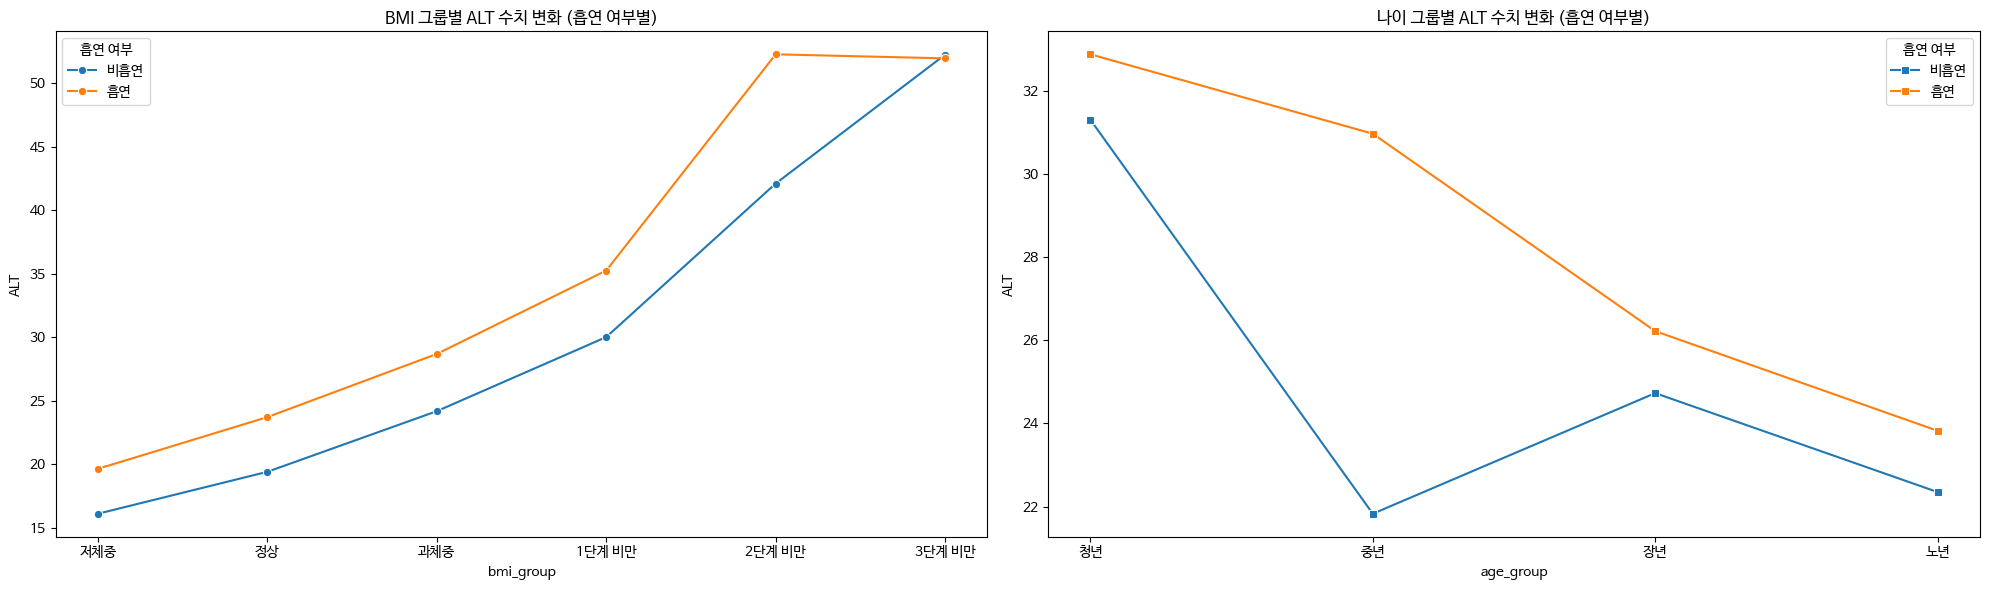

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-2: ALT 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 ALT
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='ALT', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 ALT 수치 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 ALT
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='ALT', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 ALT 수치 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
alt_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['ALT'].mean().unstack()
print("--- BMI 및 나이 그룹별 ALT 수치 요약 ---")
display(alt_table.round(2))

--- BMI 및 나이 그룹별 ALT 수치 요약 ---


smoking,0,1
bmi_group,,
저체중,16.09,19.63
정상,19.39,23.70
과체중,24.17,28.67
1단계 비만,30.00,35.24
2단계 비만,42.09,52.26
3단계 비만,52.23,51.94


### 세부가설 2-3: 흡연자는 AST 악영향

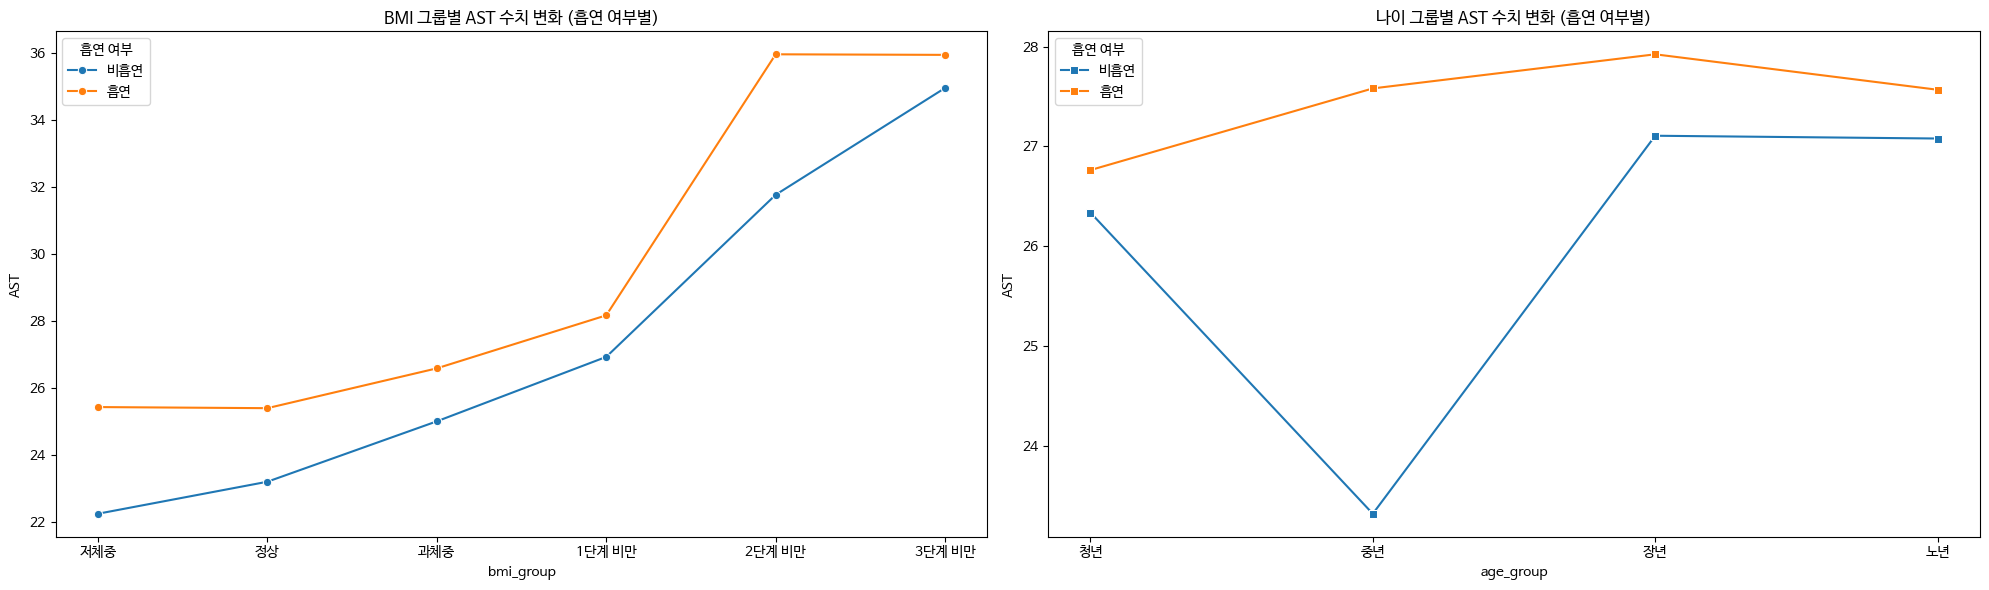

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-3: AST 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 AST
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='AST', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 AST 수치 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 AST
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='AST', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 AST 수치 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
ast_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['AST'].mean().unstack()
print("--- BMI 및 나이 그룹별 AST 수치 요약 ---")
display(ast_table.round(2))

--- BMI 및 나이 그룹별 AST 수치 요약 ---


smoking,0,1
bmi_group,,
저체중,22.25,25.44
정상,23.21,25.40
과체중,25.01,26.59
1단계 비만,26.94,28.18
2단계 비만,31.77,35.97
3단계 비만,34.96,35.95


### 세부가설 2-4: 흡연자는 허리둘래에 악영향

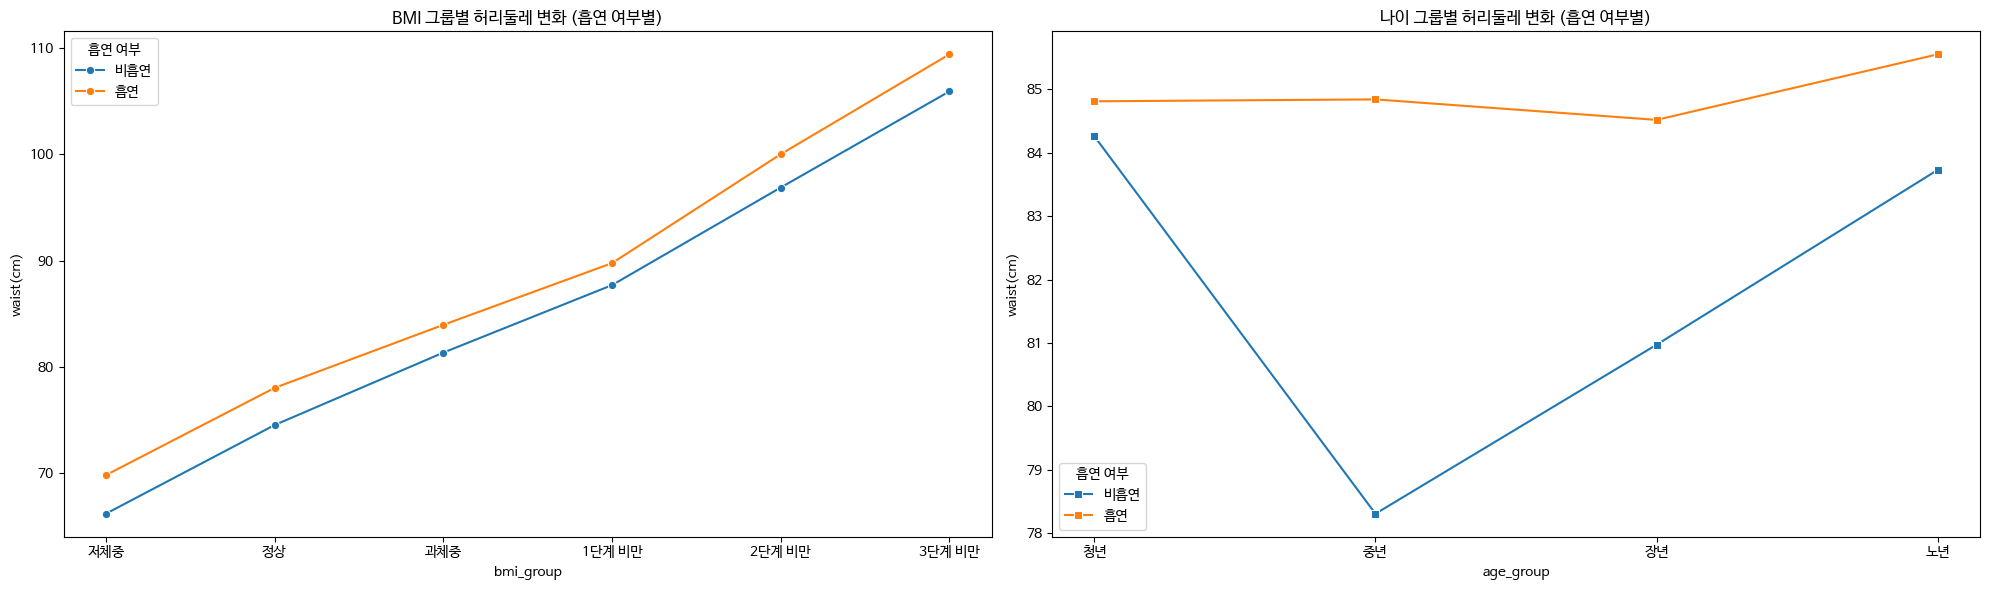

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-4: 허리둘레 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 허리둘레
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='waist(cm)', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 허리둘레 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 허리둘레
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='waist(cm)', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 허리둘레 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
waist_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['waist(cm)'].mean().unstack()
print("--- BMI 및 나이 그룹별 허리둘레 평균 ---")
display(waist_table.round(1))

--- BMI 및 나이 그룹별 허리둘레 평균 ---


smoking,0,1
bmi_group,,
저체중,66.2,69.8
정상,74.5,78.0
과체중,81.3,83.9
1단계 비만,87.7,89.7
2단계 비만,96.9,100.0
3단계 비만,105.9,109.4


#### 추가 증빙: GTP/ALT/AST/허리둘래/나이/bmi 상관 관계 계수

In [ ]:
cols_to_corr = ['Gtp', 'ALT', 'AST', 'waist(cm)', 'age', 'BMI', 'smoking']
correlation_matrix_2 = train_clean[cols_to_corr].corr()

print("--- 간 수치, 허리둘레, 나이, BMI, 흡연 여부 간의 상관계수 ---")
display(correlation_matrix_2)

--- 간 수치, 허리둘레, 나이, BMI, 흡연 여부 간의 상관계수 ---


,Gtp,ALT,AST,waist(cm),age,BMI,smoking
Gtp,1.000000,0.478899,0.427975,0.287033,-0.003054,0.219094,0.268044
ALT,0.478899,1.000000,0.741719,0.379241,-0.109019,0.360426,0.149201
AST,0.427975,0.741719,1.000000,0.201262,0.036504,0.187075,0.082912
waist(cm),0.287033,0.379241,0.201262,1.000000,-0.028091,0.821823,0.224976
age,-0.003054,-0.109019,0.036504,-0.028091,1.000000,-0.064601,-0.167949
BMI,0.219094,0.360426,0.187075,0.821823,-0.064601,1.000000,0.107735
smoking,0.268044,0.149201,0.082912,0.224976,-0.167949,0.107735,1.000000


--- 전체 지표별 상관계수 (상위 10개 행) ---


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,WHtR
age,1.000000,-0.481002,-0.325228,-0.028091,-0.330033,-0.328243,0.200329,0.205209,0.131465,0.048629,...,-0.264651,0.026229,-0.130075,0.036504,-0.109019,-0.003054,-0.111935,-0.167949,-0.064601,0.227763
height(cm),-0.481002,1.000000,0.673887,0.378606,0.239346,0.245244,-0.082092,-0.080587,0.082723,0.113511,...,0.537858,0.005258,0.442010,0.060861,0.195318,0.165969,0.083017,0.395455,0.141118,-0.125765
weight(kg),-0.325228,0.673887,1.000000,0.825186,0.165350,0.169255,-0.052458,-0.053634,0.271184,0.275084,...,0.492796,0.030737,0.373847,0.177162,0.386647,0.258274,0.077666,0.301805,0.821736,0.520380
waist(cm),-0.028091,0.378606,0.825186,1.000000,0.036375,0.039634,0.019597,0.018135,0.321334,0.294905,...,0.384973,0.043468,0.268958,0.201262,0.379241,0.287033,0.049540,0.224976,0.821823,0.868958
eyesight(left),-0.330033,0.239346,0.165350,0.036375,1.000000,0.697409,-0.090161,-0.097902,-0.035636,0.008994,...,0.142687,-0.025897,0.089925,-0.011055,0.055830,0.017279,0.021093,0.097287,0.038831,-0.090323
eyesight(right),-0.328243,0.245244,0.169255,0.039634,0.697409,1.000000,-0.091045,-0.099173,-0.027824,0.016984,...,0.147673,-0.022308,0.094108,-0.010551,0.055725,0.027052,0.029140,0.105975,0.038919,-0.090144
hearing(left),0.200329,-0.082092,-0.052458,0.019597,-0.090161,-0.091045,1.000000,0.517553,0.051733,0.005632,...,-0.030984,0.019436,0.004033,0.012536,-0.023150,0.003848,-0.020104,-0.022810,-0.006125,0.067789
hearing(right),0.205209,-0.080587,-0.053634,0.018135,-0.097902,-0.099173,0.517553,1.000000,0.044913,-0.003076,...,-0.033734,0.023076,0.007504,0.017385,-0.020315,0.004217,-0.015937,-0.020335,-0.009671,0.065149
systolic,0.131465,0.082723,0.271184,0.321334,-0.035636,-0.027824,0.051733,0.044913,1.000000,0.759383,...,0.188815,0.047263,0.079394,0.121887,0.152286,0.188559,0.033818,0.070547,0.304579,0.302375
relaxation,0.048629,0.113511,0.275084,0.294905,0.008994,0.016984,0.005632,-0.003076,0.759383,1.000000,...,0.236748,0.046224,0.094604,0.118861,0.166650,0.198893,0.035694,0.104368,0.284785,0.254853


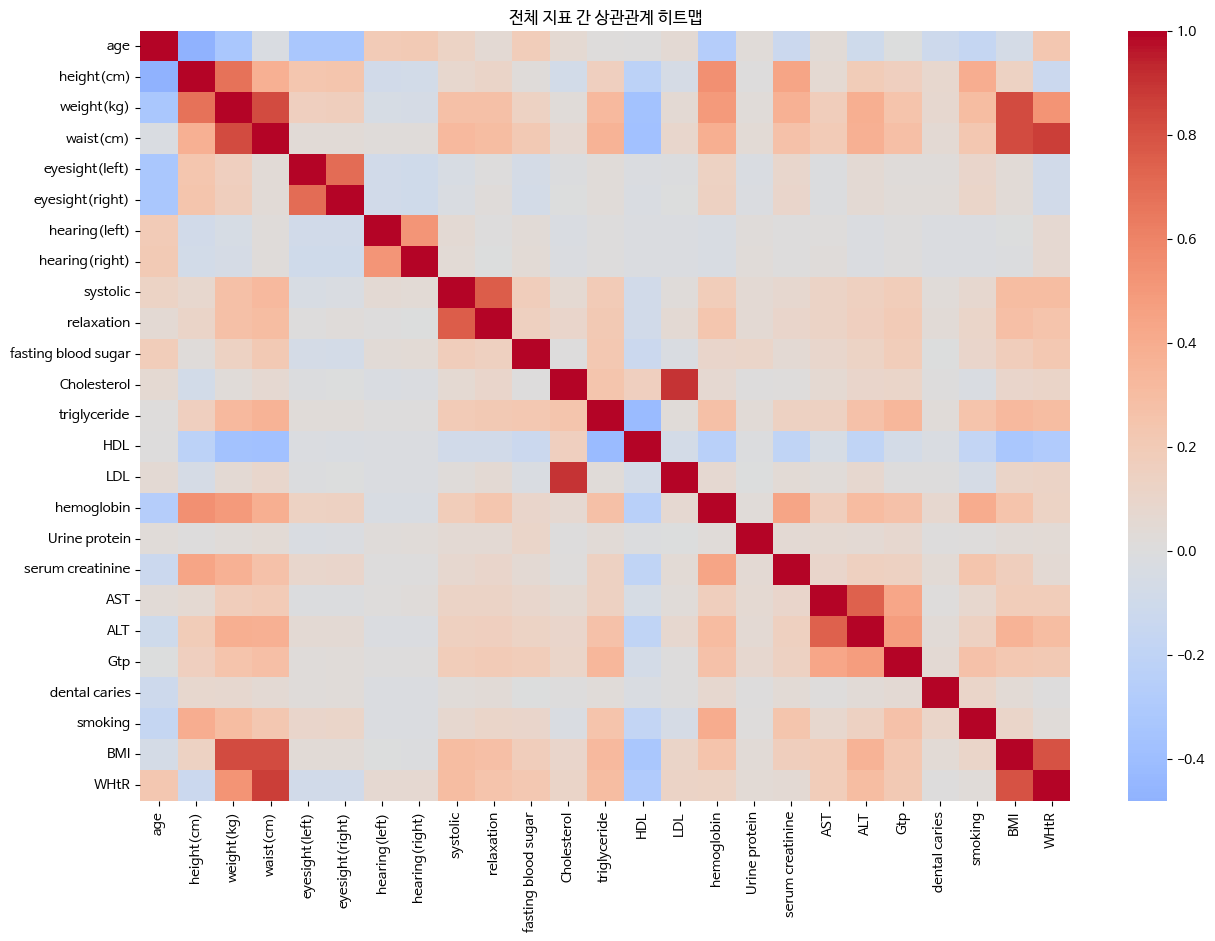

In [ ]:
# 모든 수치형 데이터 간의 상관계수 산출
full_correlation_matrix = train_clean.select_dtypes(include=[np.number]).corr()

print("--- 전체 지표별 상관계수 (상위 10개 행) ---")
display(full_correlation_matrix.head(10))

# 상관계수 히트맵 시각화
plt.figure(figsize=(15, 10))
sns.heatmap(full_correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('전체 지표 간 상관관계 히트맵')
plt.show()

### 나이, BMI, 흡연과 주요 지표 간의 상관관계 분석

--- 나이, BMI, 흡연과 타 지표 간 상관계수 표 ---


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,WHtR
age,1.000000,-0.481002,-0.325228,-0.028091,-0.330033,-0.328243,0.200329,0.205209,0.131465,0.048629,...,-0.264651,0.026229,-0.130075,0.036504,-0.109019,-0.003054,-0.111935,-0.167949,-0.064601,0.227763
BMI,-0.064601,0.141118,0.821736,0.821823,0.038831,0.038919,-0.006125,-0.009671,0.304579,0.284785,...,0.256471,0.036595,0.170304,0.187075,0.360426,0.219094,0.040746,0.107735,1.000000,0.802613
smoking,-0.167949,0.395455,0.301805,0.224976,0.097287,0.105975,-0.022810,-0.020335,0.070547,0.104368,...,0.402488,0.014296,0.247212,0.082912,0.149201,0.268044,0.107385,1.000000,0.107735,0.030364


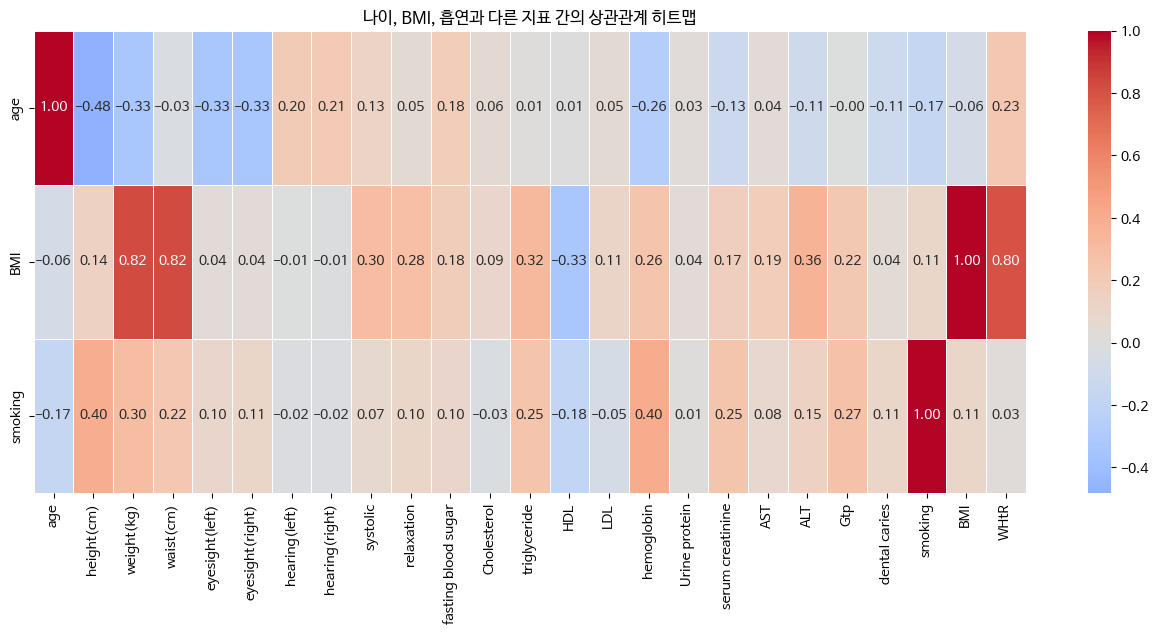

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# train_clean이 정의되어 있는지 확인하고, 필요시 이전 단계의 필터링을 다시 적용합니다.
try:
    # 분석할 대상 컬럼 정의
    target_cols = ['age', 'BMI', 'smoking']
    # 수치형 데이터 전체에 대해 상관계수 계산
    corr_matrix = train_clean.select_dtypes(include=[np.number]).corr()

    # 나이, BMI, 흡연 여부에 대한 상관계수만 추출
    selected_corr = corr_matrix[target_cols].transpose()

    print("--- 나이, BMI, 흡연과 타 지표 간 상관계수 표 ---")
    display(selected_corr)

    # 히트맵 시각화
    plt.figure(figsize=(16, 6))
    sns.heatmap(selected_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('나이, BMI, 흡연과 다른 지표 간의 상관관계 히트맵')
    plt.show()
except NameError:
    print("오류: 'train_clean' 데이터프레임이 메모리에 없습니다. 데이터 로드 및 전처리 셀을 먼저 실행해 주세요.")

### 세부가설 2-5: BMI 및 흡연 여부에 따른 WHtR 및 중성지방 분석

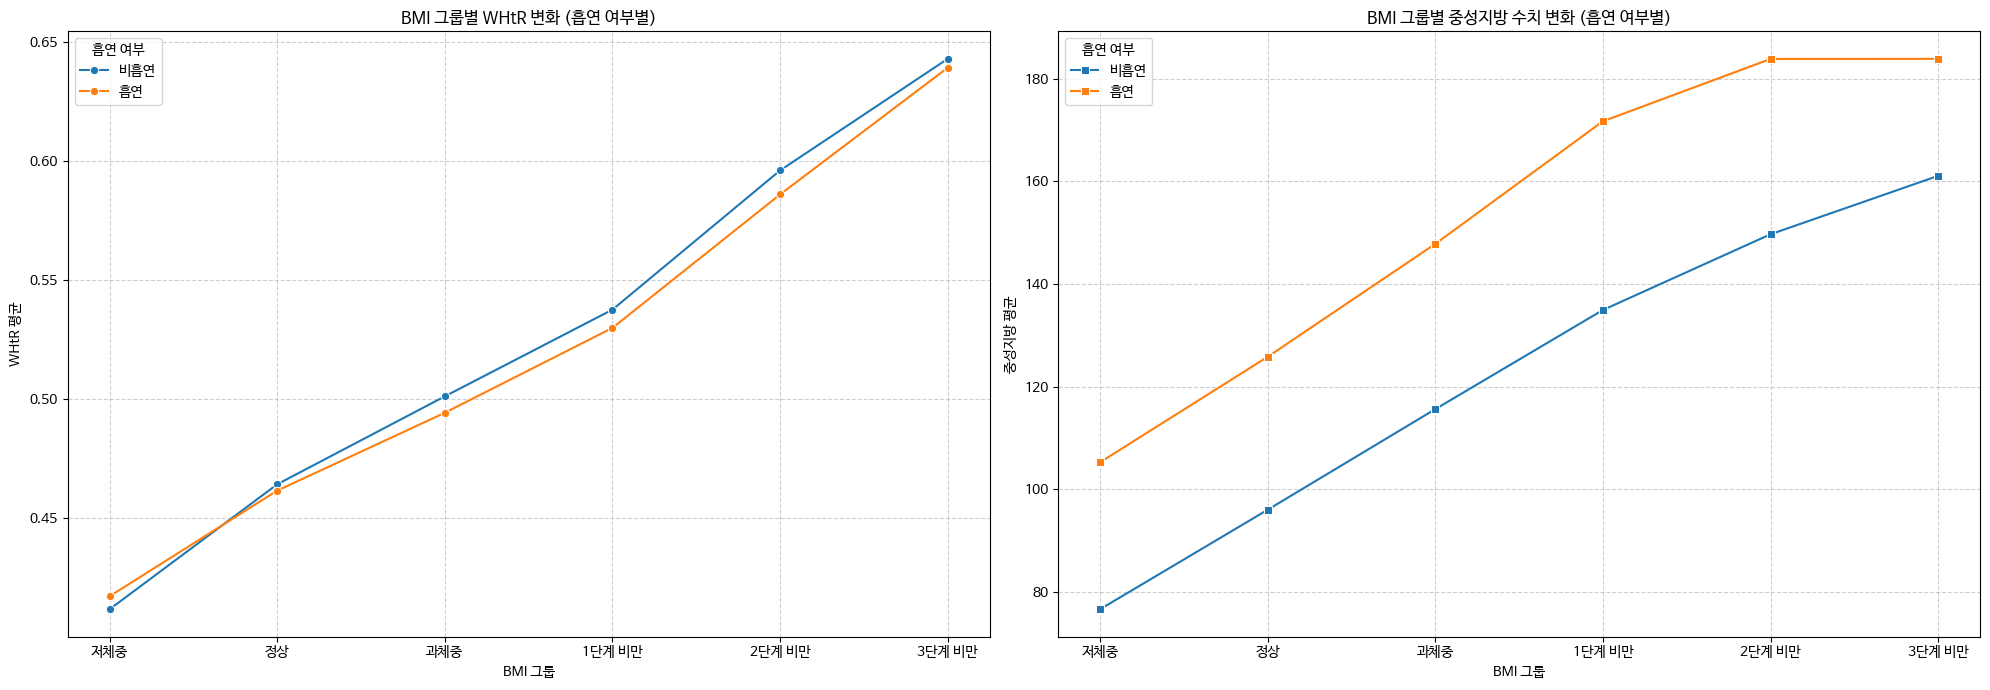

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 그룹 순서 정의
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. BMI 그룹별 WHtR (흡연 여부별)
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='WHtR', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 WHtR 변화 (흡연 여부별)')
axes[0].set_xlabel('BMI 그룹')
axes[0].set_ylabel('WHtR 평균')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. BMI 그룹별 중성지방 (Triglyceride) (흡연 여부별)
sns.lineplot(ax=axes[1], data=train_clean, x='bmi_group', y='triglyceride', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('BMI 그룹별 중성지방 수치 변화 (흡연 여부별)')
axes[1].set_xlabel('BMI 그룹')
axes[1].set_ylabel('중성지방 평균')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
whtr_trig_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)[['WHtR', 'triglyceride']].mean().unstack()
print("--- BMI 그룹별 WHtR 및 중성지방 평균 ---")
display(whtr_trig_table.round(3))

--- BMI 그룹별 WHtR 및 중성지방 평균 ---


WHtR        triglyceride         
smoking        0      1            0        1
bmi_group                                    
저체중        0.412  0.417       76.589  105.232
정상         0.464  0.462       95.976  125.789
과체중        0.501  0.494      115.588  147.799
1단계 비만     0.538  0.530      134.912  171.701
2단계 비만     0.596  0.586      149.671  183.848
3단계 비만     0.643  0.639      161.058  183.870

### 세부가설 2-6: 허리둘레와 중성지방의 상관관계 분석

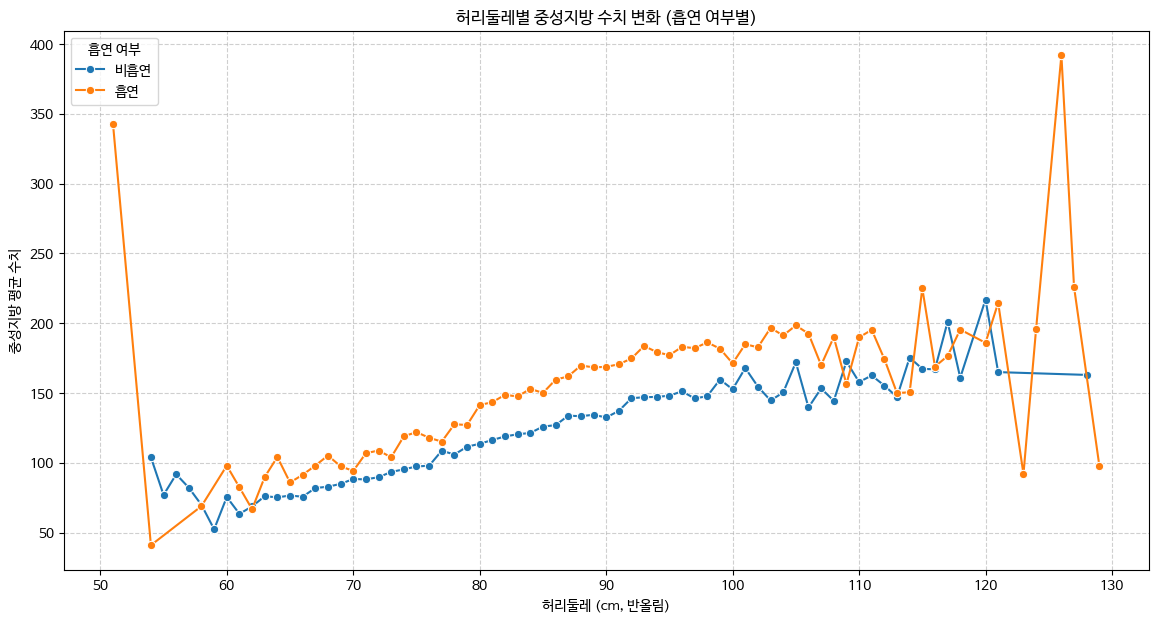

허리둘레와 중성지방 간의 전체 상관계수: 0.3610


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 허리둘레를 정수 단위로 반올림하여 그룹화 (선 그래프 시각화를 위해)
train_clean['waist_round'] = train_clean['waist(cm)'].round(0)

plt.figure(figsize=(14, 7))
sns.lineplot(data=train_clean, x='waist_round', y='triglyceride', hue='smoking', marker='o', errorbar=None)

plt.title('허리둘레별 중성지방 수치 변화 (흡연 여부별)')
plt.xlabel('허리둘레 (cm, 반올림)')
plt.ylabel('중성지방 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 상관계수 계산 및 출력
waist_trig_corr = train_clean[['waist(cm)', 'triglyceride']].corr().iloc[0, 1]
print(f'허리둘레와 중성지방 간의 전체 상관계수: {waist_trig_corr:.4f}')

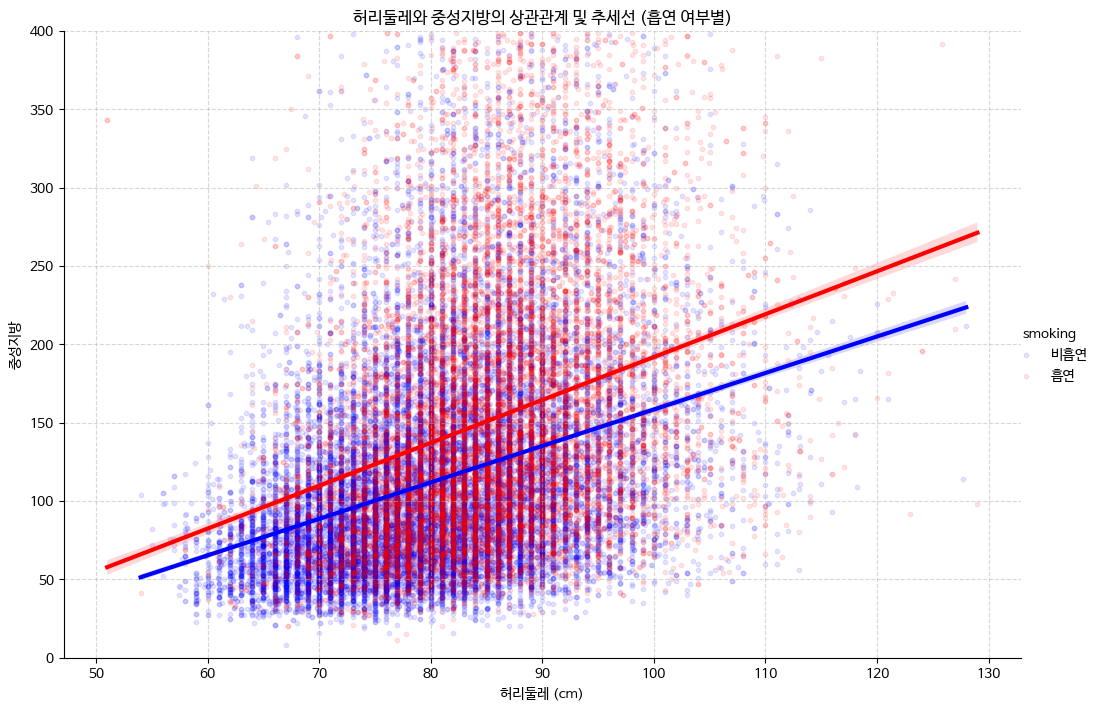

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'smoking' 값의 의미를 명확히 하여 그래프 생성 (0: 비흡연, 1: 흡연)
# y축 범위를 400으로 제한하여 가독성 향상
g = sns.lmplot(data=train_clean, x='waist(cm)', y='triglyceride', hue='smoking',
               hue_order=[0, 1], palette={0: 'blue', 1: 'red'},
               scatter_kws={'alpha':0.1, 's':10}, line_kws={'linewidth':3},
               aspect=1.5, height=7)

plt.title('허리둘레와 중성지방의 상관관계 및 추세선 (흡연 여부별)')
plt.xlabel('허리둘레 (cm)')
plt.ylabel('중성지방')

# Y축 범위 제한
plt.ylim(0, 400)

# 범례 텍스트와 색상을 명확하게 수정
new_labels = ['비흡연', '흡연']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()